In [1]:


pip install pandas seaborn matplotlib scipy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sc

In [4]:
df = pd.read_csv("WineQT.csv")

In [5]:
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [8]:
df.shape

(1143, 13)

In [9]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [10]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [11]:
df.drop('Id', axis=1, inplace=True)

In [12]:
df.duplicated().value_counts()

False    1018
True      125
Name: count, dtype: int64

In [13]:
df[df.duplicated(keep=False)]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
45,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
46,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
59,8.6,0.490,0.28,1.90,0.110,20.0,136.0,0.99720,2.93,1.95,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
1113,7.8,0.600,0.26,2.00,0.080,31.0,131.0,0.99622,3.21,0.52,9.9,5
1114,7.8,0.600,0.26,2.00,0.080,31.0,131.0,0.99622,3.21,0.52,9.9,5
1115,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1116,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5


In [14]:
df = df.drop_duplicates().reset_index(drop=True)


<Axes: >

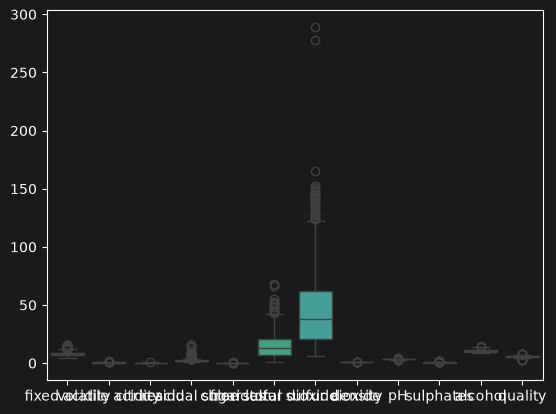

In [15]:
sns.boxplot(data=df)

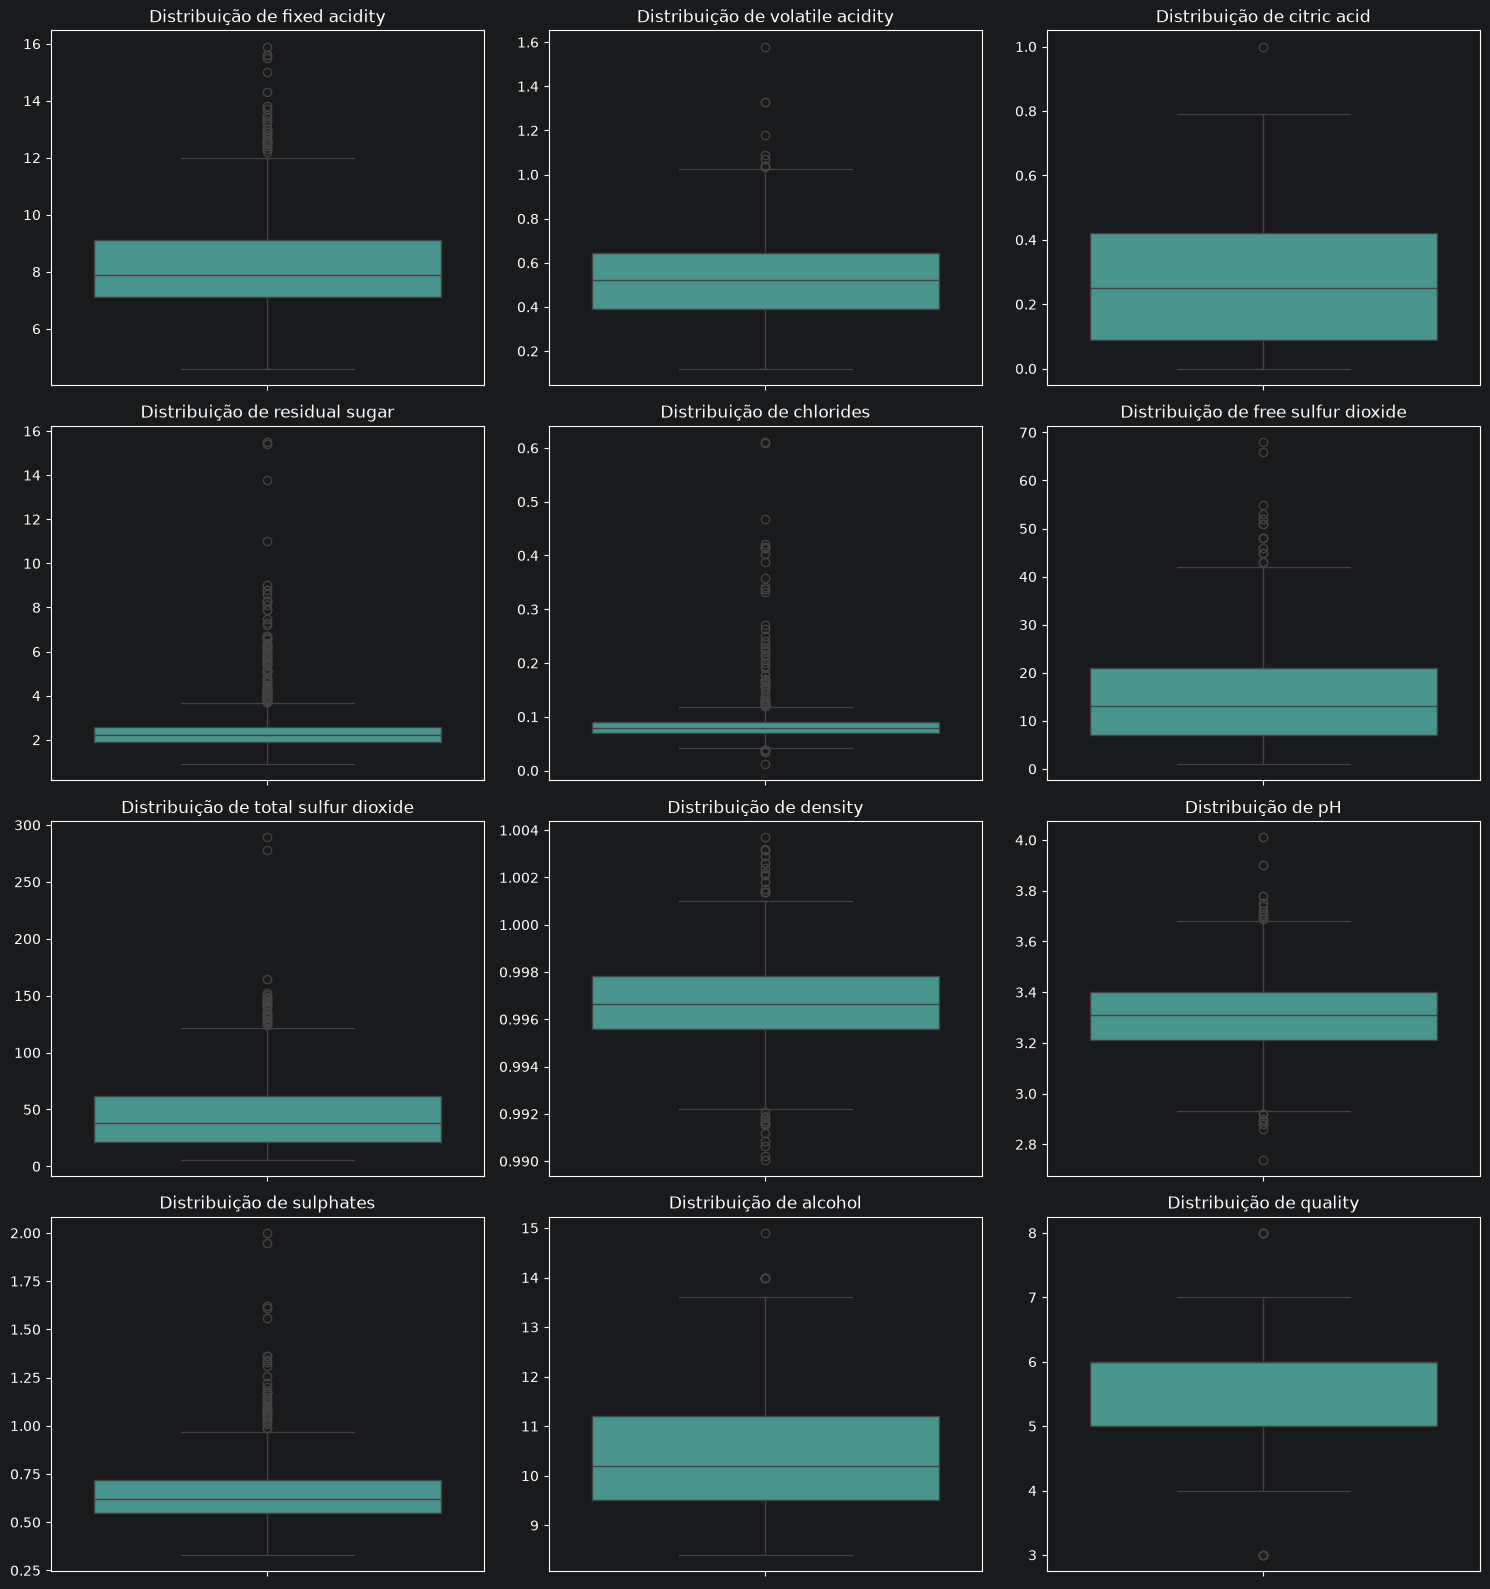

In [16]:

import math

colunas = df.select_dtypes(include=['number']).columns

num_colunas_grid = 3
num_linhas_grid = math.ceil(len(colunas) / num_colunas_grid)

fig, axes = plt.subplots(num_linhas_grid, num_colunas_grid, figsize=(15, 4 * num_linhas_grid))
axes = axes.flatten()  # Transforma a matriz em lista para facilitar o loop

for i, col in enumerate(colunas):
    sns.boxplot(y=df[col], ax=axes[i], color='#3ca197') # Cor similar à do seu gráfico
    axes[i].set_title(f'Distribuição de {col}', fontsize=12)
    axes[i].set_ylabel('')  # Remove rótulo repetido do eixo Y

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [17]:
import numpy as np


# 1. CRIANDO AS COLUNAS TRANSFORMADAS EM LOG
# Mantemos as originais salvas e criamos novas para aplicar o IQR
df['chlorides_log'] = np.log(df['chlorides'])
df['residual_sugar_log'] = np.log(df['residual sugar'])

# 2. DEFININDO OS GRUPOS DE COLUNAS E SEUS RESPECTIVOS MULTIPLICADORES
# Ajuste os nomes das colunas de acordo com o seu dataset real
colunas_simetricas = ['fixed acidity', 'volatile acidity', 'citric acid']  # Exemplo 1.5x
colunas_intermediarias = ['free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol']  # Exemplo 3x
colunas_assimetricas_log = ['chlorides_log', 'residual_sugar_log']  # Log + IQR de sua escolha (ex: 1.5x)

# Criamos uma cópia para filtrar as linhas sem perder o DataFrame original



# 3. FUNÇÃO PARA RETORNAR MÁSCARA BOOLEANA DOS OUTLIERS
def obter_mascara_outliers(df_coluna, multiplicador):
    q1 = df_coluna.quantile(0.25)
    q3 = df_coluna.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - multiplicador * iqr
    limite_superior = q3 + multiplicador * iqr

    # Retorna True onde o dado é considerado um outlier
    return (df_coluna < limite_inferior) | (df_coluna > limite_superior)


# 4. APLICANDO O FILTRO EM CADEIA
outliers_totais = pd.Series(False, index=df.index)

# Aplicando 1.5x nas simétricas
for col in colunas_simetricas:
    outliers_totais = outliers_totais | obter_mascara_outliers(df[col], 1.5)

# Aplicando 3.0x nas intermediárias
for col in colunas_intermediarias:
    outliers_totais = outliers_totais | obter_mascara_outliers(df[col], 3.0)

# Aplicando na versão LOG das assimétricas (sugestão: 1.5x ou 3.0x conforme seu teste)
for col in colunas_assimetricas_log:
    outliers_totais = outliers_totais | obter_mascara_outliers(df[col], 3.0)

# 5. REMOVENDO OS OUTLIERS DO DATASET
df_final = df[~outliers_totais]

# Verificando o tamanho final do dataset
print(f"Formato original: {df.shape}")
print(f"Formato após a remoção híbrida: {df_final.shape}")
print(f"Total de linhas removidas: {df.shape[0] - df_final.shape[0]}")


Formato original: (1018, 14)
Formato após a remoção híbrida: (922, 14)
Total de linhas removidas: 96


In [18]:
df_final = df_final.copy()
df_final['faixa_qualidade'] = pd.cut(df_final['quality'], bins=[2, 5, 6, 8], labels=['baixa', 'media', 'alta'], ordered=True)
df_final['razao_so2_livre'] = df_final['free sulfur dioxide'] / df_final['total sulfur dioxide']

In [19]:
df_final['faixa_qualidade'].value_counts()

faixa_qualidade
baixa    429
media    369
alta     124
Name: count, dtype: int64

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"
BLUE = "#2a78d6"
RAMP = {"baixa": "#86b6ef", "media": "#2a78d6", "alta": "#104281"}
ROTULO_FAIXA = {"baixa": "baixa (3–5)", "media": "média (6)", "alta": "alta (7–8)"}

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "font.family": "DejaVu Sans",
    "text.color": INK,
    "axes.labelcolor": INK2,
    "axes.edgecolor": AXIS,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False,
    "legend.fontsize": 9,
})


def estilo(ax, eixo_grade="y"):
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.spines["left"].set_color(AXIS)
    ax.spines["bottom"].set_color(AXIS)
    ax.grid(axis=eixo_grade, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)


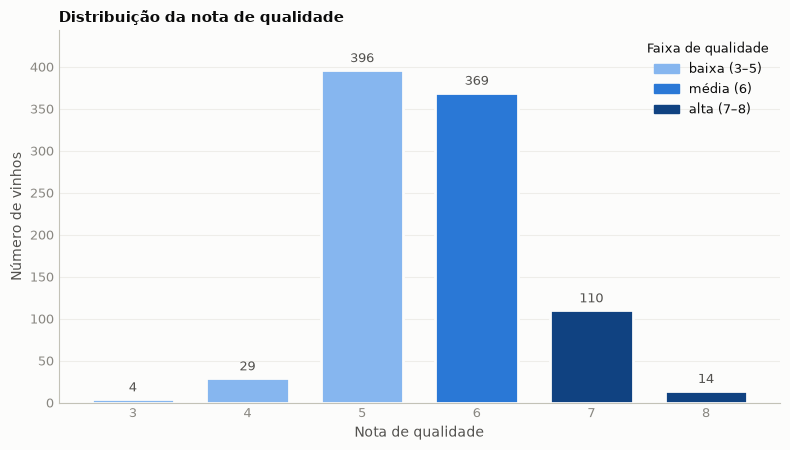

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.6))
contagem = df_final["quality"].value_counts().sort_index()
cores = [RAMP["baixa"] if q <= 5 else RAMP["media"] if q == 6 else RAMP["alta"] for q in contagem.index]
ax.bar(contagem.index, contagem.values, width=0.72, color=cores, edgecolor=SURFACE, linewidth=2)
for x, y in zip(contagem.index, contagem.values):
    ax.text(x, y + 6, str(y), ha="center", va="bottom", fontsize=9, color=INK2)
ax.set_xlabel("Nota de qualidade")
ax.set_ylabel("Número de vinhos")
ax.set_title("Distribuição da nota de qualidade", loc="left")
ax.set_xticks(contagem.index)
ax.set_ylim(0, contagem.max() * 1.12)
estilo(ax)
ax.legend(
    handles=[Patch(color=RAMP[k], label=ROTULO_FAIXA[k]) for k in ("baixa", "media", "alta")],
    title="Faixa de qualidade",
    title_fontsize=9,
    loc="upper right",
)
fig.tight_layout()
plt.show()

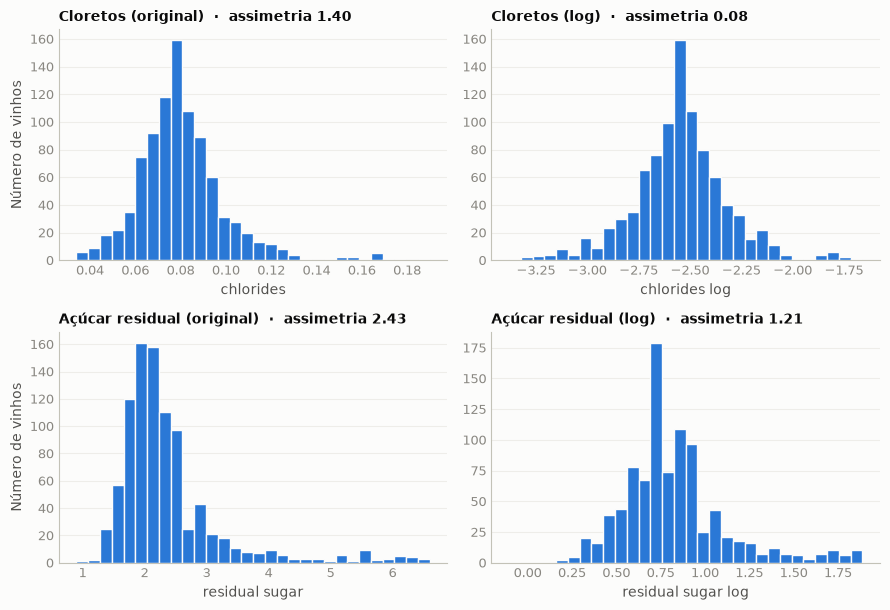

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6.2))
pares = [
    ("chlorides", "Cloretos (original)", "chlorides_log", "Cloretos (log)"),
    ("residual sugar", "Açúcar residual (original)", "residual_sugar_log", "Açúcar residual (log)"),
]
for i, (original, titulo_original, versao_log, titulo_log) in enumerate(pares):
    for j, (coluna, titulo) in enumerate([(original, titulo_original), (versao_log, titulo_log)]):
        ax = axes[i, j]
        ax.hist(df_final[coluna], bins=30, color=BLUE, edgecolor=SURFACE, linewidth=1)
        ax.set_title(f"{titulo}  ·  assimetria {df_final[coluna].skew():.2f}", loc="left", fontsize=10)
        ax.set_ylabel("Número de vinhos" if j == 0 else "")
        ax.set_xlabel(coluna.replace("_", " "))
        estilo(ax)
fig.tight_layout()
plt.show()

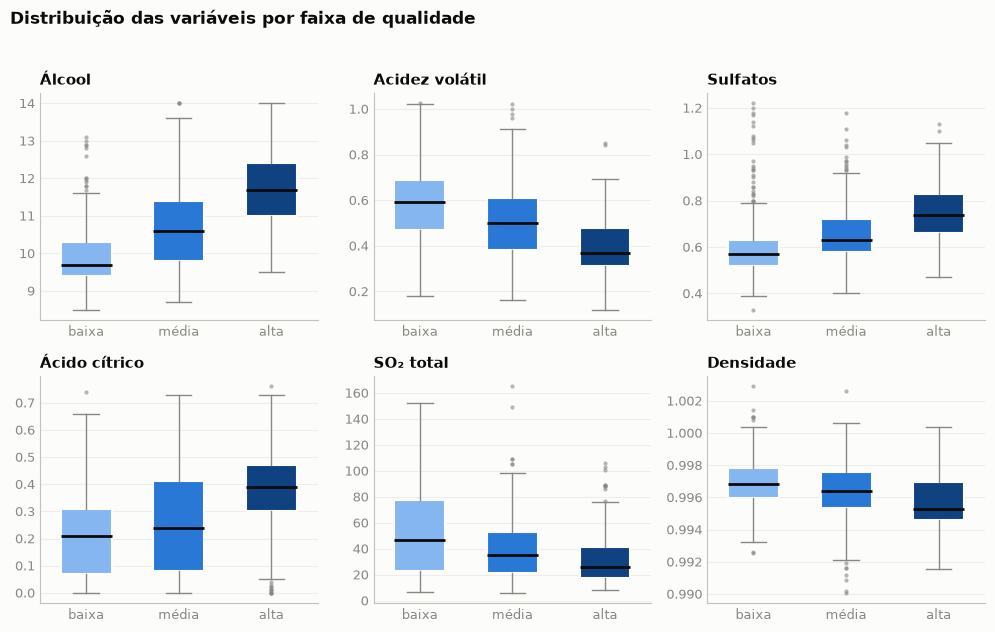

In [23]:
variaveis_box = [
    ("alcohol", "Álcool"),
    ("volatile acidity", "Acidez volátil"),
    ("sulphates", "Sulfatos"),
    ("citric acid", "Ácido cítrico"),
    ("total sulfur dioxide", "SO₂ total"),
    ("density", "Densidade"),
]
ordem_faixas = ["baixa", "media", "alta"]
fig, axes = plt.subplots(2, 3, figsize=(10, 6.4))
for ax, (coluna, nome) in zip(axes.ravel(), variaveis_box):
    dados = [df_final.loc[df_final["faixa_qualidade"] == f, coluna] for f in ordem_faixas]
    caixas = ax.boxplot(
        dados,
        patch_artist=True,
        widths=0.55,
        showfliers=True,
        flierprops=dict(marker="o", markersize=3, markerfacecolor=MUTED, markeredgecolor="none", alpha=0.6),
        medianprops=dict(color=INK, linewidth=2),
        whiskerprops=dict(color=MUTED, linewidth=1),
        capprops=dict(color=MUTED, linewidth=1),
        boxprops=dict(linewidth=1.5, edgecolor=SURFACE),
    )
    for caixa, f in zip(caixas["boxes"], ordem_faixas):
        caixa.set_facecolor(RAMP[f])
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["baixa", "média", "alta"])
    ax.set_title(nome, loc="left")
    estilo(ax)
fig.suptitle("Distribuição das variáveis por faixa de qualidade", x=0.01, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

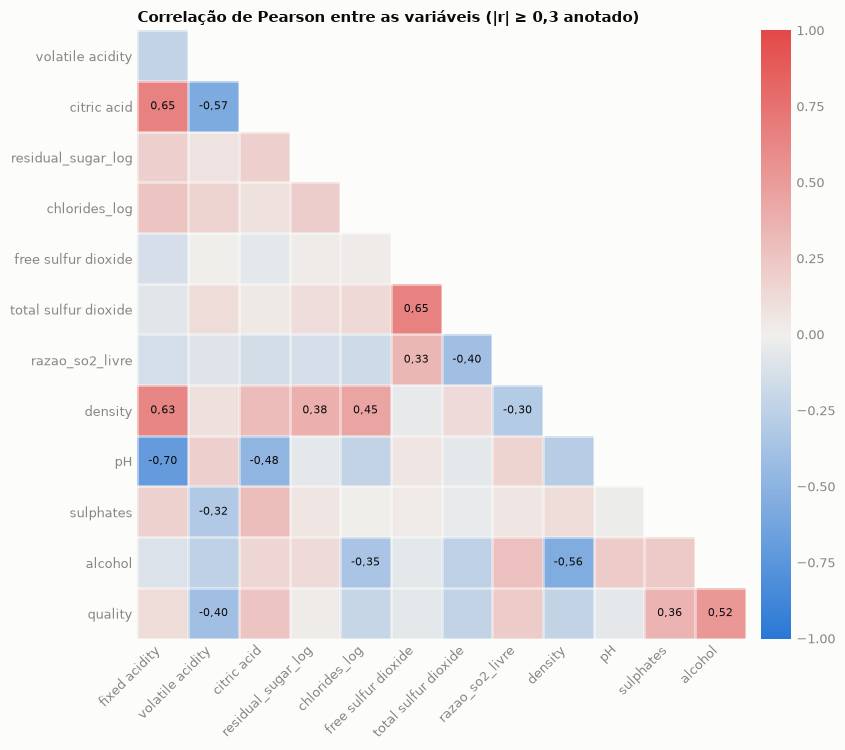

In [24]:
colunas_corr = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual_sugar_log",
    "chlorides_log",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "razao_so2_livre",
    "density",
    "pH",
    "sulphates",
    "alcohol",
    "quality",
]
corr = df_final[colunas_corr].corr().iloc[1:, :-1]
rotulos_linhas = colunas_corr[1:]
rotulos_colunas = colunas_corr[:-1]
mapa_cores = LinearSegmentedColormap.from_list("divergente", ["#2a78d6", "#f0efec", "#e34948"])
n = len(rotulos_linhas)
mascara = np.triu(np.ones((n, n), dtype=bool), k=1)
matriz = np.ma.array(corr.values, mask=mascara)
fig, ax = plt.subplots(figsize=(9, 7.6))
imagem = ax.imshow(matriz, cmap=mapa_cores, vmin=-1, vmax=1)
for i in range(n):
    for j in range(n):
        valor = corr.values[i, j]
        if not mascara[i, j] and abs(valor) >= 0.3:
            ax.text(j, i, f"{valor:.2f}".replace(".", ","), ha="center", va="center", fontsize=8,
                    color="#ffffff" if abs(valor) >= 0.7 else INK)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(rotulos_colunas, rotation=45, ha="right")
ax.set_yticklabels(rotulos_linhas)
for borda in ax.spines.values():
    borda.set_visible(False)
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="both", length=0)
ax.set_title("Correlação de Pearson entre as variáveis (|r| ≥ 0,3 anotado)", loc="left")
barra = fig.colorbar(imagem, ax=ax, fraction=0.04, pad=0.02)
barra.outline.set_visible(False)
barra.ax.tick_params(length=0)
fig.tight_layout()
plt.show()

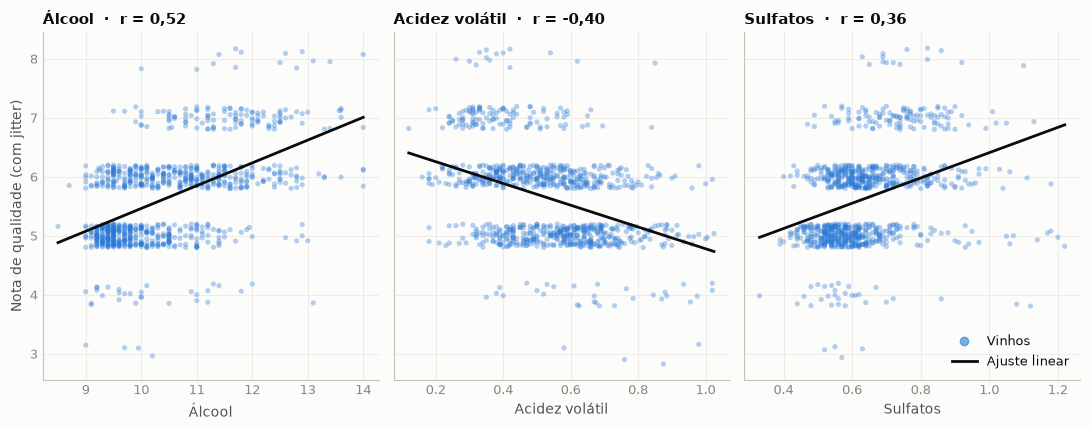

In [25]:
rng = np.random.default_rng(42)
principais = [("alcohol", "Álcool"), ("volatile acidity", "Acidez volátil"), ("sulphates", "Sulfatos")]
fig, axes = plt.subplots(1, 3, figsize=(11, 4.4), sharey=True)
for ax, (coluna, nome) in zip(axes, principais):
    y_jitter = df_final["quality"] + rng.uniform(-0.2, 0.2, len(df_final))
    ax.scatter(df_final[coluna], y_jitter, s=14, color=BLUE, alpha=0.35, edgecolor="none")
    inclinacao, intercepto = np.polyfit(df_final[coluna], df_final["quality"], 1)
    xs = np.linspace(df_final[coluna].min(), df_final[coluna].max(), 50)
    ax.plot(xs, inclinacao * xs + intercepto, color=INK, linewidth=2)
    r = df_final[coluna].corr(df_final["quality"])
    ax.set_title(f"{nome}  ·  r = {r:.2f}".replace(".", ","), loc="left")
    ax.set_xlabel(nome)
    estilo(ax, eixo_grade="both")
axes[0].set_ylabel("Nota de qualidade (com jitter)")
axes[0].set_yticks(range(3, 9))
axes[-1].legend(
    handles=[
        Line2D([0], [0], marker="o", linestyle="", color=BLUE, alpha=0.6, markersize=6, label="Vinhos"),
        Line2D([0], [0], color=INK, linewidth=2, label="Ajuste linear"),
    ],
    loc="lower right",
)
fig.tight_layout()
plt.show()

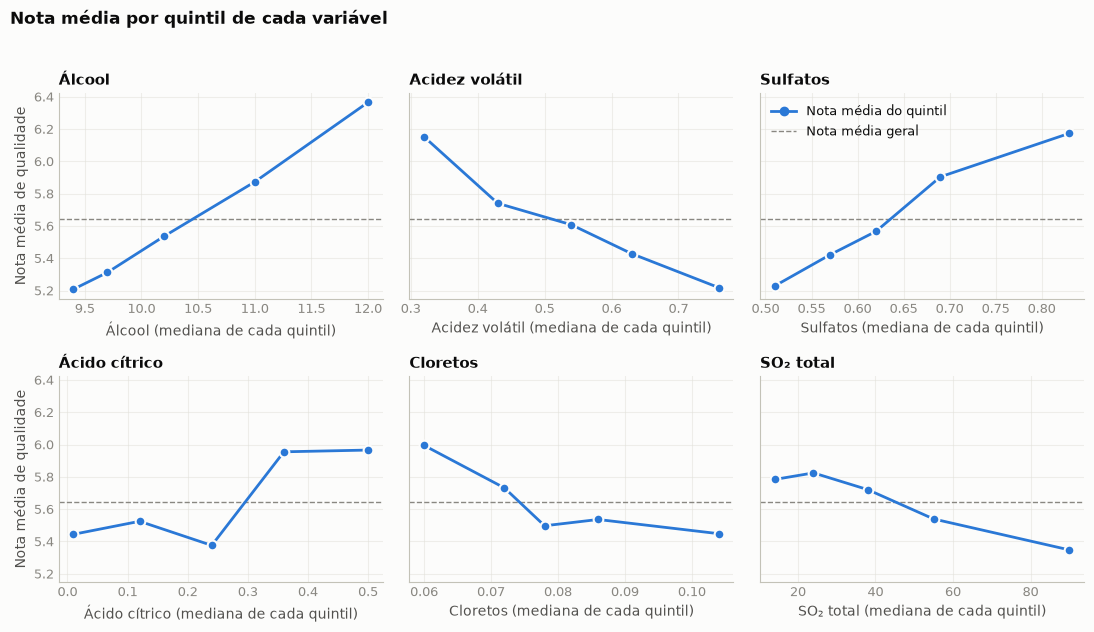

In [28]:
perfis = [
    ("alcohol", "Álcool"),
    ("volatile acidity", "Acidez volátil"),
    ("sulphates", "Sulfatos"),
    ("citric acid", "Ácido cítrico"),
    ("chlorides", "Cloretos"),
    ("total sulfur dioxide", "SO₂ total"),
]
media_geral = df_final["quality"].mean()
fig, axes = plt.subplots(2, 3, figsize=(11, 6.4), sharey=True)
for ax, (coluna, nome) in zip(axes.ravel(), perfis):
    quintis = pd.qcut(df_final[coluna], 5, duplicates="drop")
    resumo = df_final.groupby(quintis, observed=True).agg(x=(coluna, "median"), media=("quality", "mean"))
    ax.axhline(media_geral, color=MUTED, linewidth=1, linestyle="--")
    ax.plot(resumo["x"], resumo["media"], color=BLUE, linewidth=2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.set_title(nome, loc="left")
    ax.set_xlabel(f"{nome} (mediana de cada quintil)")
    estilo(ax, eixo_grade="both")
axes[0, 0].set_ylabel("Nota média de qualidade")
axes[1, 0].set_ylabel("Nota média de qualidade")
axes[0, 2].legend(
    handles=[
        Line2D([0], [0], color=BLUE, linewidth=2, marker="o", markersize=6, label="Nota média do quintil"),
        Line2D([0], [0], color=MUTED, linewidth=1, linestyle="--", label="Nota média geral"),
    ],
    loc="upper left",
)
fig.suptitle("Nota média por quintil de cada variável", x=0.01, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

In [29]:
print('pinto')

pinto
